In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file= pd.read_excel("Customer_demographics.xlsx")
file.shape

(20, 14)

In [12]:
file.iloc[0]

CustomerID                       C001
Age                                25
Gender                         Female
City                           Mumbai
IncomeLevel                    Medium
EducationLevel               Bachelor
MaritalStatus                  Single
NumberOfChildren                    0
PurchaseFrequencyPerMonth           5
AveragePurchaseAmount            2500
PreferredCategory            Clothing
OnlineShoppingPercentage           80
LoyaltyProgramMember              Yes
LastCampaignResponse              Yes
Name: 0, dtype: object

In [14]:
file.isnull().sum()

CustomerID                   0
Age                          0
Gender                       0
City                         0
IncomeLevel                  0
EducationLevel               0
MaritalStatus                0
NumberOfChildren             0
PurchaseFrequencyPerMonth    0
AveragePurchaseAmount        0
PreferredCategory            0
OnlineShoppingPercentage     0
LoyaltyProgramMember         0
LastCampaignResponse         0
dtype: int64

In [16]:
file.duplicated().sum()

np.int64(0)

The business wants a visual report on customer demographics and purchasing habits to inform their next marketing campaign.

Text(0.5, 1.0, 'Purchasing power of an age group')

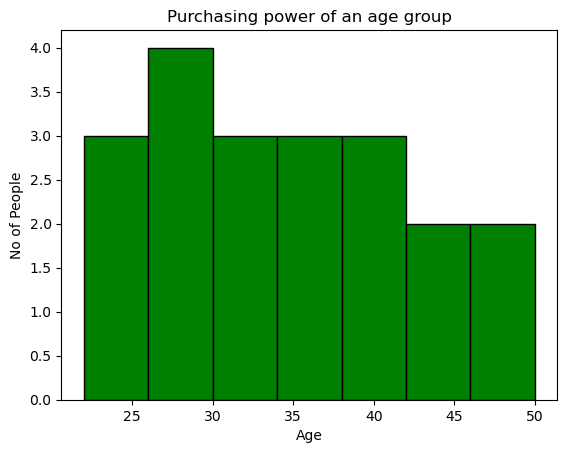

In [58]:
#Identify the purchasing power of an age group 
# Use Histogram to show the distribution of a single numerical variable.

plt.hist(file["Age"], bins=7, color = "green", edgecolor="black") 
plt.ylabel("No of People")
plt.xlabel("Age")
plt.title("Purchasing power of an age group") 

#Observation: The data shows higher purchasing power lies within people who ages are between 25 to 30 and the least being with ages greater than 45.

Text(0.5, 1.0, 'Influence of Gender and Marital Status on Purchase Frequency')

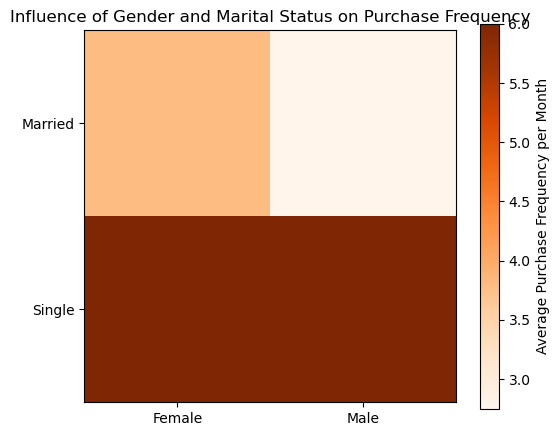

In [59]:
#Understand the influence of the purchase based on Gender and marital status.
#Rationale: Use heatmap to understand the frequency of the event, in a grid format.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

gender = file["Gender"]
status = file["MaritalStatus"]
purchase = file["PurchaseFrequencyPerMonth"]

heatmap_data = file.pivot_table(
    values="PurchaseFrequencyPerMonth",
    index="MaritalStatus",
    columns="Gender",
    aggfunc="mean"   # average purchase frequency
)

plt.figure(figsize=(6,5))
plt.imshow(heatmap_data, cmap="Oranges")

plt.xticks( ticks=np.arange(len(heatmap_data.columns)),labels=heatmap_data.columns)
plt.yticks( ticks=np.arange(len(heatmap_data.index)),labels=heatmap_data.index)

plt.colorbar(label="Average Purchase Frequency per Month")
plt.title("Influence of Gender and Marital Status on Purchase Frequency")

#Observation: Regardless of the gender, people with single status have a higher purchase power.

Text(0.5, 1.0, 'city that has high spending capacity')

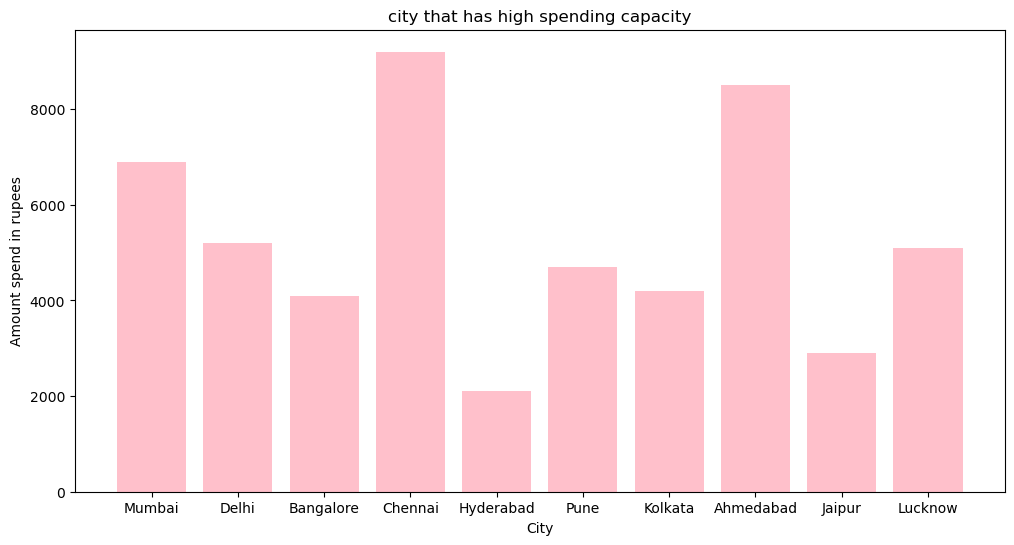

In [60]:
#Identify the city that has high spending capacity
#Rationale: Use bar chart, which is excellent for comparing categorical data, between city and average purchase amount

city= file["City"]
amount= file["AveragePurchaseAmount"]
plt.figure(figsize=(12,6))
plt.bar(city, amount, color="pink")
plt.xlabel ("City")
plt.ylabel("Amount spend in rupees")
plt.title ("city that has high spending capacity")

#Observation: Chennai  has the highest spending capacity (>8000rs), whilst Hyderbad has the least(<3000rs).


Text(0.5, 1.0, 'online shopping percentage and purchase frequency')

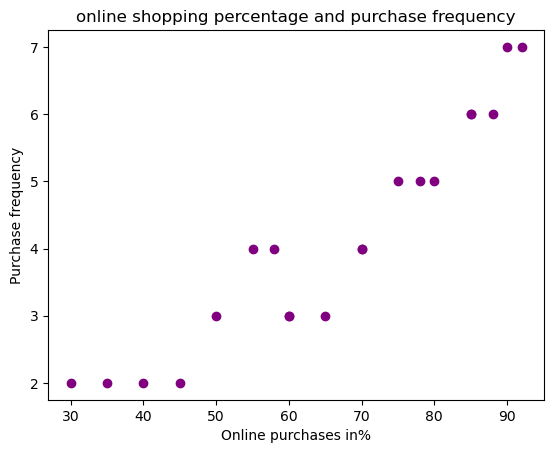

In [48]:
#Understand any relation between online shopping percentage and purchase frequency.
#Rationale: Using a scatterplot to show the relationship between two numerical variables. 
online= file["OnlineShoppingPercentage"]
purchase= file["PurchaseFrequencyPerMonth"]

plt.scatter(online, purchase, color= "purple")
plt.xlabel("Online purchases in%")
plt.ylabel("Purchase frequency")
plt.title("online shopping percentage and purchase frequency")

C:\Users\vssen\AppData\Local\Temp\ipykernel_28844\2106813369.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data,labels = labels)


Text(0.5, 1.0, 'Distribution of amount spent based on their membership status')

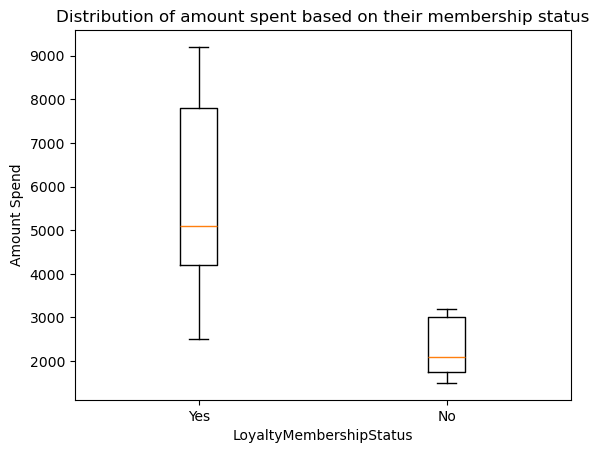

In [57]:
#Understand if the possession of loyalty card influences the spending amount.
#Rationale: Use boxplot to show the distribution of amount spent based on their membership status.

file1 = file[file["LoyaltyProgramMember"] == "Yes"]
file2 = file[file["LoyaltyProgramMember"] == "No"]

data = [
    file1["AveragePurchaseAmount"],
    file2["AveragePurchaseAmount"]
]

labels = ["Yes", "No"]

plt.boxplot(data,labels = labels)
plt.xlabel("LoyaltyMembershipStatus")
plt.ylabel("Amount Spend")
plt.title ("Distribution of amount spent based on their membership status")


Conclusion:
Suggestions to boost sales would be 
to promote business to audience aged greater than 25
To introduce new products tailored to married individuals to improve purchase in that segment.
Make more business adverts in hyderabad to improve customer numbers.
Give more offers when purchased online, thereby allowing customers to use online platform more, which shows improved purchase frequency.
Introduce new schemes, to allow easy switch for non members into loyaltyMembership Status, thereby improving spend capacity.
